# 01 Data Sources

Purpose: document sample cities, data sources, field definitions, source reliability, and coverage.

## Research Scope

- **20 Chinese cities** selected across four economic tiers
- **2021–2025 panel** (post-COVID recovery through '14th Five-Year Plan' completion)
- **15+ indicators** → 6 YEOI sub-scores (job opportunity, starting income, living cost, enterprise opportunity, growth potential, city base)
- Multi-source strategy: government bulletins, mirrors, financial media, databases

### City Tier Classification

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

CITY_TIERS = {
    'megacity': ['Beijing', 'Shanghai', 'Shenzhen', 'Guangzhou'],
    'strong_second_tier': ['Hangzhou', 'Nanjing', 'Suzhou', 'Chengdu', 'Wuhan', "Xi'an"],
    'transition': ['Hefei', 'Changsha', 'Qingdao', 'Xiamen', 'Zhengzhou', 'Chongqing'],
    'control': ['Harbin', 'Shenyang', 'Kunming', 'Nanchang'],
}

tier_rows = []
for tier, cities in CITY_TIERS.items():
    for city in cities:
        tier_rows.append({'tier': tier, 'city': city})
tier_df = pd.DataFrame(tier_rows)
display(tier_df.groupby('tier')['city'].apply(lambda x: ', '.join(x)).reset_index())

,tier,city
0,control,"Harbin, Shenyang, Kunming, Nanchang"
1,megacity,"Beijing, Shanghai, Shenzhen, Guangzhou"
2,strong_second_tier,"Hangzhou, Nanjing, Suzhou, Chengdu, Wuhan, Xi'an"
3,transition,"Hefei, Changsha, Qingdao, Xiamen, Zhengzhou, C..."


## 1. Data Source Tiering Strategy

| Tier | Source Type | Examples | is_official |
|------|------------|----------|-------------|
| **T1** | Government bulletins & reports | City statistics bureau communiqués, budget reports, yearbooks | ✅ True |
| **T2** | Official mirrors & state media | hongheiku.com, tjcn.org, People's Daily, Xinhua | ❌ False |
| **T3** | Financial media & databases | CEIC, Caixin, Sina Finance, The Paper, jiemian.com | ❌ False |
| **T4** | Public knowledge bases | Wikipedia, bond rating reports (chinamoney), academic datasets | ❌ False |

All non-official sources retain a source URL and are marked `is_official_source=False`.

Total observations: 1286
  Official sources: 458 (36%)
  Non-official sources: 828


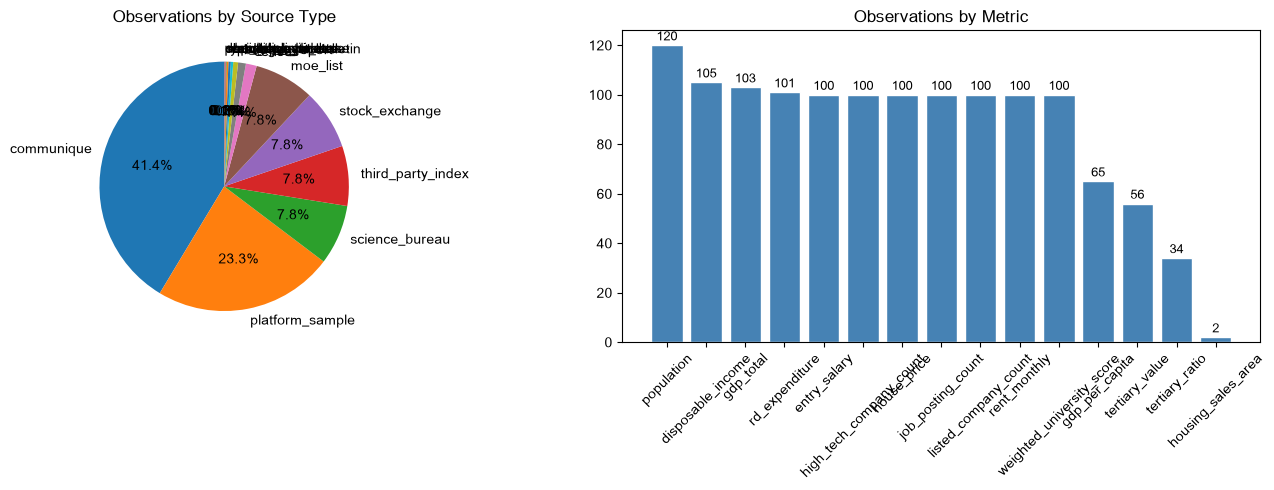

In [10]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
obs = pd.read_csv(ROOT / 'data' / 'raw' / 'source_observations.csv')
print(f'Total observations: {len(obs)}')
print(f'  Official sources: {obs["is_official_source"].sum()} ({obs["is_official_source"].mean()*100:.0f}%)')
print(f'  Non-official sources: {(~obs["is_official_source"]).sum()}')

# Source distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By source_type
src_counts = obs['source_type'].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Observations by Source Type')

# By metric
metric_counts = obs['metric'].value_counts()
axes[1].bar(metric_counts.index, metric_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Observations by Metric')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(metric_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Coverage Heatmap

City × Year × Metric coverage before and after the data completion round.

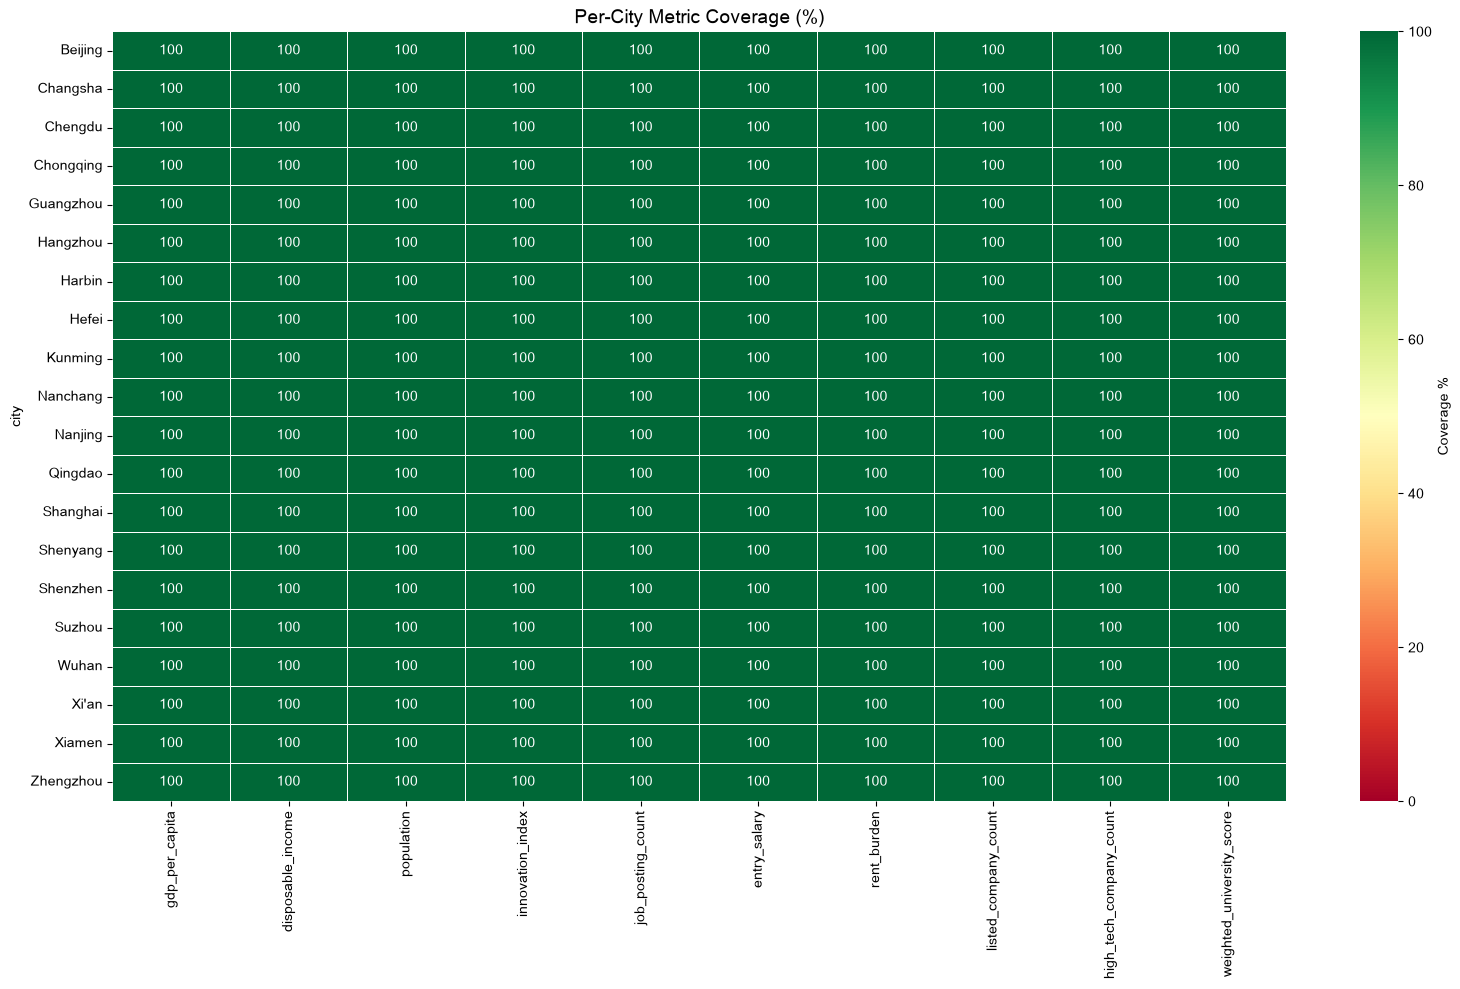

In [11]:
import numpy as np
import seaborn as sns

panel = pd.read_csv(ROOT / 'data' / 'raw' / 'city_panel.csv')
metrics = ['gdp_per_capita', 'disposable_income', 'population', 'innovation_index',
           'job_posting_count', 'entry_salary', 'rent_burden', 'listed_company_count',
           'high_tech_company_count', 'weighted_university_score']
all_cities = sorted(panel['city'].unique())

# Build coverage matrix: city x metric
coverage_data = []
for city in all_cities:
    row = {'city': city}
    for metric in metrics:
        sub = panel[(panel['city'] == city)]
        if metric in sub.columns:
            filled = sub[metric].notna().sum()
            row[metric] = filled / len(sub)
        else:
            row[metric] = 0.0
    coverage_data.append(row)
cov_df = pd.DataFrame(coverage_data).set_index('city')

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(cov_df * 100, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coverage %'})
ax.set_title('Per-City Metric Coverage (%)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Field Definitions

| Field | Unit | Source | Notes |
|-------|------|--------|-------|
| `gdp_per_capita` | yuan/person | Statistical communiqué / derived from gdp_total÷population | Priority: communiqué direct extraction |
| `disposable_income` | yuan/person | Statistical communiqué | All-resident preferred; urban used when all-resident unavailable |
| `population` | person | Statistical communiqué / census | Year-end permanent resident (changzhu renkou) |
| `house_price` | yuan/sqm | China Index Academy / gotohui annual mean | All cities use new-home price in yuan/sqm |
| `housing_burden` | ratio | Derived: house_price / disposable_income | Higher = more housing pressure |
| `rent_monthly` | yuan/month | Platform data (ke.com, anjuke) | City average monthly rent |
| `rent_burden` | ratio | Derived: rent_monthly × 12 / disposable_income | Higher = more rent pressure |
| `innovation_index` | 100 million yuan | Budget reports / provincial S&T bulletins | Narrow caliber: general public budget science & technology expenditure |
| `rd_expenditure` | 100 million yuan | Budget reports / R&D bulletins | Separate column for R&D expenditure |
| `weighted_university_score` | quality score | MOE 985/211/university list | Weighted: 985×5 + 211(non-985)×2.5 + other×0.3; 2025 data, repeated across years |
| `listed_company_count` | count | Stock exchange data | A-share listed companies headquartered in city |
| `high_tech_company_count` | count | Torch Center / provincial science bureaus | National high-tech enterprise count (2021-2025) |
| `job_posting_count` | count | Platform data (zhaopin, 51job) | Annual job postings |
| `entry_salary` | yuan/month | Platform data (zhaopin, 51job) | Average entry-level salary for fresh graduates |
| `tertiary_ratio` | % | Statistical communiqué | Tertiary sector share of GDP (supplementary) |

## 4. Observations Count by Year & Metric

year,2020,2021,2022,2023,2024,2025
metric,,,,,,
disposable_income,5,20,20,20,20,20
entry_salary,0,20,20,20,20,20
gdp_per_capita,1,13,14,13,13,11
gdp_total,5,19,20,20,19,20
high_tech_company_count,0,20,20,20,20,20
house_price,0,20,20,20,20,20
housing_sales_area,0,1,0,1,0,0
job_posting_count,0,20,20,20,20,20
listed_company_count,0,20,20,20,20,20


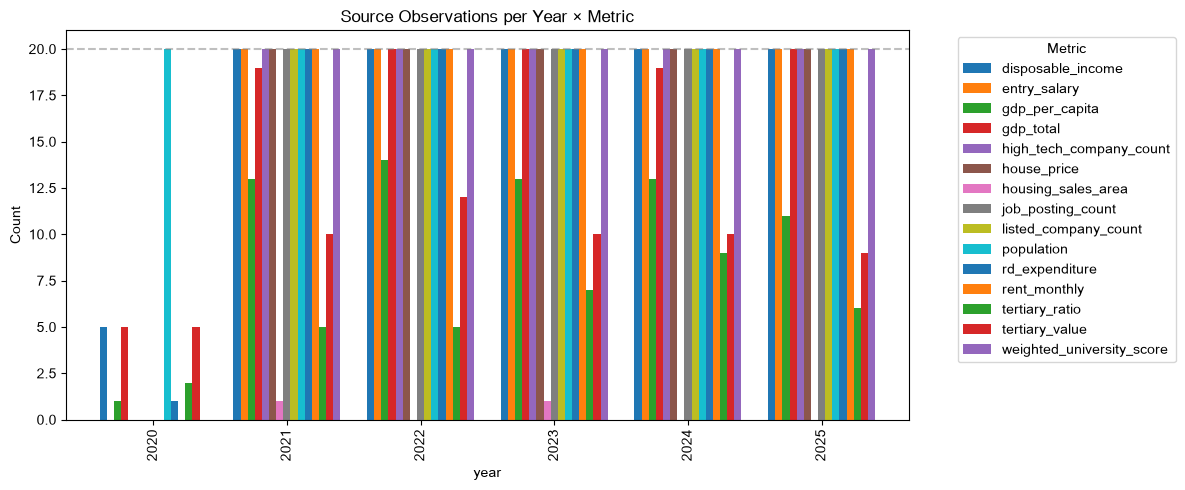

In [12]:
pivot = obs.pivot_table(index='metric', columns='year', values='value', aggfunc='count', fill_value=0)
display(pivot)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Source Observations per Year × Metric')
ax.set_ylabel('Count')
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1))
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='20 cities target')
plt.tight_layout()
plt.show()

## 5. Remaining Gaps

Only 4 `rd_expenditure` gaps remain (all 2025, awaiting official publication):
- Chengdu, Hefei, Kunming, Nanchang

**Expected release**: Sep–Oct 2026 (budget final accounts).

See `data/raw/missing_data_summary.md` for full gap tracking history.

In [8]:
missing = pd.read_csv(ROOT / 'data' / 'raw' / 'missing_data_report.csv')
if len(missing) == 0:
    print('✅ No missing data gaps!')
else:
    display(missing)
    print(f'\n{len(missing)} remaining gaps')

,city,year,metric,data_tier,category,status,attempted_sources,explanation
0,Beijing,2021,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
1,Beijing,2022,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
2,Beijing,2023,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
3,Beijing,2024,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
4,Beijing,2025,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
...,...,...,...,...,...,...,...,...
63,Harbin,2025,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
64,Kunming,2023,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
65,Kunming,2025,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...
66,Nanchang,2021,tertiary_ratio,unknown,supplementary,not_found,communique/yearbook/nbs_api/external_csv/platform,Official source value not found in current sou...



68 remaining gaps
